In [1]:
from pathlib import Path

project_root = Path(".").resolve().parent.parent.parent
assert project_root.name == "pep-compass"

In [2]:
import pandas as pd

parents = pd.read_csv(
    project_root
    / "results/data/veltri_negative.csv"
)
mutants = pd.read_csv(
    project_root
    / "results/data/mutants/veltri_negative/veltri_negative_direction_threshold=0.001_token_threshold=0.1_jacobian_mode=approx.csv"
)

In [3]:
display(parents.head())
display(mutants.head())

,Name,Sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,E. coli AIG222,K. pneumoniae ATCC 13883,P. aeruginosa PA01,P. aeruginosa PA14,S. aureus ATCC 12600,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511180,139.801180,137.902370,140.05830,138.364410,137.98553,136.774020,141.596900,...,408.06840,299.70337,142.26360,141.87341,134.63571,2463.8271,106.403625,1105.36780,646.91650,131.340040
1,UniRef50_Q9FKB0,ELIDRCIGSKIWVIMKGDKELVGILKG,89.528824,118.419390,119.541725,128.80423,100.891540,90.99354,102.825260,70.190704,...,252.05864,210.20215,129.42552,130.82336,113.55690,1169.5818,61.302850,516.47375,488.59735,83.926080
2,UniRef50_P33768,QNIQDRIKMYIKKEEEEPTNFKNPF,130.894900,115.837326,114.040790,131.67166,119.030320,124.43645,127.947815,118.429825,...,396.36917,304.71548,133.56018,129.68240,100.20509,1961.2029,79.325660,943.49840,455.85287,114.144104
3,UniRef50_O42888,GEGITPANIAISWAVKRGTSVLPKSVNESRIVS,134.440840,133.998600,130.942200,133.20078,139.556900,138.98576,135.156510,126.896560,...,425.77026,311.65692,138.77722,139.58517,133.83589,2635.2510,103.507120,1179.88680,699.80206,126.254190
4,UniRef50_P51657,GCSSGIGLHLAVRLASDRSQSFKVYATLRDLKSQGPLLEAARA,115.702190,121.632590,119.013330,127.29396,122.310265,120.87968,124.867210,95.488450,...,372.47662,279.35890,136.31871,129.34870,119.17818,2587.9010,87.836210,1226.76670,667.98175,109.741745


,mutant,position,parent,direction_significance_threshold,token_threshold,parent_name,parent_sequence,A. baumannii ATCC 19606,E. coli ATCC 11775,E. coli AIG221,...,B. ovatus ATCC8483,E. rectale ATCC33656,C. symbiosum,R. obeum,R. torques,E. coli Nissle,Salmonella enterica ATCC 9150 (BEIRES NR-515),Salmonella enterica (BEIRES NR-170),Salmonella enterica ATCC 9150 (BEIRES NR-174),L. monocytogenes ATCC 19111 (BEIRES NR-106)
0,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004
1,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.28995,140.26088,138.06827,...,425.31943,311.48676,143.79056,144.51553,138.30191,2539.0486,108.815346,1091.2412,676.61480,133.30217
2,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004
3,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.28995,140.26088,138.06827,...,425.31943,311.48676,143.79056,144.51553,138.30191,2539.0486,108.815346,1091.2412,676.61480,133.30217
4,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.51120,139.80118,137.90237,...,408.06845,299.70350,142.26358,141.87337,134.63573,2463.8271,106.403660,1105.3683,646.91644,131.34004


In [4]:
import numpy as np
from typing import Literal, Optional


def compute_diff(
    parents_df: pd.DataFrame,
    mutants_df: pd.DataFrame,
    match_col_parents: str,
    match_col_mutants: str,
    value_cols: list[str],
    value_preprocessing: Optional[Literal["log"]],
    add_relative: bool,
) -> pd.DataFrame:
    """
    Compute the difference between the mutants and parents for each value column.
    """
    merged = mutants_df.merge(
        parents_df,
        left_on=match_col_mutants,
        right_on=match_col_parents,
        suffixes=("_mutants", "_parents"),
    )
    if value_preprocessing is None:
        vprep_fn = lambda x: x
    elif value_preprocessing == "log":
        vprep_fn = np.log2
    else:
        raise ValueError(f"Invalid value_preprocessing: {value_preprocessing}")
    if value_preprocessing is None:
        value_preprocessing = ""
    else:
        value_preprocessing = "_" + value_preprocessing

    for value_col in value_cols:
        merged[f"{value_col}{value_preprocessing}_diff"] = vprep_fn(
            merged[f"{value_col}_mutants"]
        ) - vprep_fn(merged[f"{value_col}_parents"])
        if add_relative:
            merged[f"{value_col}{value_preprocessing}_diff_relative"] = merged[
                f"{value_col}{value_preprocessing}_diff"
            ] / vprep_fn(merged[f"{value_col}_parents"])
    return merged

In [5]:
mic_bac_columns = parents.head().columns.tolist()[2:]

In [6]:
diff = compute_diff(
    parents_df=parents,
    mutants_df=mutants,
    match_col_parents="Name",
    match_col_mutants="parent_name",
    value_cols=mic_bac_columns,
    value_preprocessing=None,
    add_relative=True,
)

In [7]:
diff

,mutant,position,parent,direction_significance_threshold,token_threshold,parent_name,parent_sequence,A. baumannii ATCC 19606_mutants,E. coli ATCC 11775_mutants,E. coli AIG221_mutants,...,E. coli Nissle_diff,E. coli Nissle_diff_relative,Salmonella enterica ATCC 9150 (BEIRES NR-515)_diff,Salmonella enterica ATCC 9150 (BEIRES NR-515)_diff_relative,Salmonella enterica (BEIRES NR-170)_diff,Salmonella enterica (BEIRES NR-170)_diff_relative,Salmonella enterica ATCC 9150 (BEIRES NR-174)_diff,Salmonella enterica ATCC 9150 (BEIRES NR-174)_diff_relative,L. monocytogenes ATCC 19111 (BEIRES NR-106)_diff,L. monocytogenes ATCC 19111 (BEIRES NR-106)_diff_relative
0,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.0000,0.000000,0.000035,3.289362e-07,0.00050,4.523381e-07,-0.00006,-9.274767e-08,0.000000,0.000000
1,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.289950,140.260880,138.068270,...,75.2215,0.030530,2.411721,2.266578e-02,-14.12660,-1.278000e-02,29.69830,4.590747e-02,1.962130,0.014939
2,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.0000,0.000000,0.000035,3.289362e-07,0.00050,4.523381e-07,-0.00006,-9.274767e-08,0.000000,0.000000
3,EGAVSGVEGLPSGSAN,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,139.289950,140.260880,138.068270,...,75.2215,0.030530,2.411721,2.266578e-02,-14.12660,-1.278000e-02,29.69830,4.590747e-02,1.962130,0.014939
4,EGAVSGVEGLPSGSAL,15,EGAVSGVEGLPSGSAL,0.001,0.1,UniRef50_A0QYG2,EGAVSGVEGLPSGSAL,138.511200,139.801180,137.902370,...,0.0000,0.000000,0.000035,3.289362e-07,0.00050,4.523381e-07,-0.00006,-9.274767e-08,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250859,GWAYKTVQEEDLPFPLIYG,12,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,134.072510,134.489000,129.866320,...,745.0060,0.420790,10.208304,1.079607e-01,78.78020,6.955347e-02,86.90950,1.455323e-01,11.551390,0.104938
250860,GWAYKTVQELDLKFPLIYG,9,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,123.425930,129.777940,121.619040,...,235.2943,0.132898,-3.272030,-3.460423e-02,-4.13990,-3.655035e-03,6.90860,1.156864e-02,-4.692170,-0.042626
250861,GWAYKTVQEEDLKFPLIRG,17,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,119.093765,124.244995,117.214294,...,-417.7583,-0.235956,-8.417920,-8.902597e-02,-146.84615,-1.296475e-01,-49.76080,-8.332581e-02,-8.481145,-0.077046
250862,GWAYKTVQEEDLKFPIIYG,15,GWAYKTVQEEDLKFPLIYG,0.001,0.1,UniRef50_Q05AL2,GWAYKTVQEEDLKFPLIYG,126.570755,130.751600,124.777610,...,63.3651,0.035790,0.308226,3.259727e-03,16.59210,1.464883e-02,9.27440,1.553023e-02,1.484930,0.013490


In [ ]:
import pandas as pd
import numpy as np

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")


diff_clean = diff.dropna(subset=["parent", "mutant", "position"]).drop_duplicates(subset=["parent", "mutant", "position"])


mask = (
    (diff_clean["position"] < diff_clean["parent"].str.len()) &
    (diff_clean["position"] < diff_clean["mutant"].str.len())
)
diff_clean = diff_clean[mask]

delta_cols = [col for col in diff.columns if col.endswith("_diff")]

diff_clean["parent_aa"] = diff_clean.apply(lambda r: r["parent"][r["position"]], axis=1)
diff_clean["mutant_aa"] = diff_clean.apply(lambda r: r["mutant"][r["position"]], axis=1)

diff_clean = diff_clean[diff_clean["parent_aa"] != diff_clean["mutant_aa"]]

mutation_matrix = pd.DataFrame(
    [[[] for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

for aa_pair, group in diff_clean.groupby(["parent_aa", "mutant_aa"]):
    p_aa, m_aa = aa_pair
    mutation_matrix.at[p_aa, m_aa] = group[delta_cols].to_numpy()


example_list = mutation_matrix.at["A", "T"]


In [30]:
example_list = mutation_matrix.at["A", "C"]
example_list.shape
example_list

array([[ 1.2599000e-01,  5.8190000e-01,  1.2061400e+00,  2.2216000e-01,
        -8.0840000e-01, -7.7992000e-01, -4.5120000e-02,  1.4120000e-01,
        -3.1123500e-01,  4.5357000e-01,  6.3511000e-01,  1.1589300e+00,
         1.4984600e+00, -2.0030000e-02,  5.0935000e-01,  1.3252000e-01,
         1.8564000e-01, -2.4013000e-01,  1.2860000e-01,  6.3620000e-01,
        -5.8421000e-01,  2.1851000e-01,  1.1762200e+00, -2.7240200e+00,
        -5.8908100e+00, -5.3657500e+00,  2.7933000e-01,  7.3046000e-01,
         1.1201900e+00, -7.4264800e+01,  2.9823000e-01, -1.4885000e+01,
        -1.6392400e+01,  8.2180000e-01],
       [ 6.9244000e-01,  9.6772000e-01,  2.2121600e+00,  1.3709600e+00,
         1.2456600e+00,  1.3228300e+00,  2.1281000e+00,  2.9334900e+00,
         2.4745300e+00,  1.3578300e+00, -7.9471000e-01,  1.8172900e+00,
        -1.2343600e+00,  9.2260000e-01,  1.0894600e+00,  1.5082200e+00,
         2.7223500e+00,  2.5821700e+00,  1.0678500e+00,  2.3496700e+00,
         2.0742500e+00,

In [35]:
# Prepare empty mean matrix
mean_diffs_matrix = pd.DataFrame(
    [[None for _ in ALL_AA] for _ in ALL_AA],
    index=ALL_AA,
    columns=ALL_AA
)

# Compute mean ΔMIC per mutation cell
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vectors = mutation_matrix.at[p_aa, m_aa]  # list of ΔMIC vectors
        if len(vectors) > 0:
            mean_diffs_matrix.at[p_aa, m_aa] = np.mean(vectors, axis=0)  # mean per bacterium
        else:
            mean_diffs_matrix.at[p_aa, m_aa] = np.zeros(len(delta_cols))  # or np.nan

In [39]:
mic_bac_columns

['A. baumannii ATCC 19606',
 'E. coli ATCC 11775',
 'E. coli AIG221',
 'E. coli AIG222',
 'K. pneumoniae ATCC 13883',
 'P. aeruginosa PA01',
 'P. aeruginosa PA14',
 'S. aureus ATCC 12600',
 'S. aureus (ATCC BAA-1556) - MRSA',
 'vancomycin-resistant E. faecalis ATCC 700802',
 'vancomycin-resistant E. faecium ATCC 700221',
 'A. muciniphila ATCC BAA-835',
 'B. fragilis ATCC25285',
 'B. vulgatus ATCC8482',
 'C. aerofaciens ATCC25986',
 'C. scindens ATCC35704',
 'B. thetaiotaomicron ATCC29148',
 'B. thetaiotaomicron Complemmented',
 'B. thetaiotaomicron Mutant',
 'B. uniformis ATCC8492',
 'B. eggerthi ATCC27754',
 'C. spiroforme ATCC29900',
 'P. distasonis ATCC8503',
 'P. copri DSMZ18205',
 'B. ovatus ATCC8483',
 'E. rectale ATCC33656',
 'C. symbiosum',
 'R. obeum',
 'R. torques',
 'E. coli Nissle',
 'Salmonella enterica ATCC 9150 (BEIRES NR-515)',
 'Salmonella enterica (BEIRES NR-170)',
 'Salmonella enterica ATCC 9150 (BEIRES NR-174)',
 'L. monocytogenes ATCC 19111 (BEIRES NR-106)']

In [41]:
gram_neg = [0, 1, 2, 3, 4, 5, 6, 11, 12, 13, 16, 17, 18, 19, 20, 23, 24, 25, 30, 31, 32, 33]
gram_pos = [7, 8, 9, 10, 14, 15, 21, 26, 27, 28, 29, 34]

In [54]:
import numpy as np
import pandas as pd

ALL_AA = list("ACDEFGHIKLMNPQRSTVWY")

# mean_diffs_matrix: each cell = np.array of ΔMIC means (length 34)

# Prepare matrices for mean MIC change per group
mean_gram_neg_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)
mean_gram_pos_matrix = pd.DataFrame(index=ALL_AA, columns=ALL_AA)

# Compute group means
for p_aa in ALL_AA:
    for m_aa in ALL_AA:
        vector = mean_diffs_matrix.at[p_aa, m_aa]
        if vector is not None and isinstance(vector, (list, np.ndarray)) and len(vector) > 0:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_neg if i < len(vector)])
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nanmean([vector[i] for i in gram_pos if i < len(vector)])
        else:
            mean_gram_neg_matrix.at[p_aa, m_aa] = np.nan
            mean_gram_pos_matrix.at[p_aa, m_aa] = np.nan

# Example: get average ΔMIC for mutation A -> T
print("Gram-negative mean", mean_gram_neg_matrix)
print("Gram-positive mean", mean_gram_pos_matrix)


Gram-negative mean           A         C         D         E         F         G         H  \
A       0.0  2.172294  2.224441  0.157239 -0.781448 -0.761487 -1.305511   
C -1.934629       0.0  1.538369 -2.337172 -1.837487 -3.404144  0.720135   
D -2.523215  0.608951       0.0  -1.52665  -2.25945 -2.424841 -2.286595   
E -0.102947  1.328947  1.543223       0.0 -1.429337  -0.94329 -0.175674   
F   0.77596  2.569466  1.894403  1.917288       0.0  0.668504  0.826703   
G  0.540564  3.218787   2.46348  1.079523 -0.177163       0.0 -0.236678   
H  1.073364  0.345881  0.945652    0.5105 -1.474054  0.369503       0.0   
I  2.285438   4.15555  4.786644  3.274185  2.382128   2.08277  4.332857   
K  6.299869  6.949134  7.443226  6.060184  5.361611  5.178036  6.755664   
L  2.048909  4.003286   3.71555  3.728641  1.153312  1.641103   2.55411   
M -2.464507   1.30635 -0.335089 -3.312899 -3.100117 -2.927053 -3.688697   
N  1.028661  4.152683  3.665001  2.616109  0.768087 -0.752217  1.479082   
P -1.3

In [55]:
# -*- coding: utf-8 -*-
# Amino acid classifications (1-letter codes, standard 20 proteinogenic amino acids)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

AMINO_ACID_CLASSES = {
    "polarity": {
        "hydrophobic": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
        "polar": ["S", "T", "Y", "C", "N", "Q"],
        "charged": ["K", "R", "H", "D", "E"],
    },

    "charge": {
        "positive": ["K", "R", "H"],
        "negative": ["D", "E"],
        "neutral": [
            "A", "V", "L", "I", "M", "F", "W", "P", "G",
            "S", "T", "Y", "C", "N", "Q"
        ],
    },

    "chemical_type": {
        "aliphatic": ["G", "A", "V", "L", "I"],
        "aromatic": ["F", "Y", "W"],
        "hydroxyl": ["S", "T", "Y"],
        "acidic": ["D", "E"],
        "amide": ["N", "Q"],
        "basic": ["K", "R", "H"],
        "sulfur": ["C", "M"],
        "imino": ["P"],
        # "other": [],  # placeholder (no gaps)
    },

    "essentiality": {
        "essential": ["F", "V", "T", "W", "M", "L", "I", "K", "H"],
        "non_essential": ["A", "N", "D", "E", "Q", "G", "P", "S", "C", "Y"],
    },

    "aromaticity": {
        "aromatic": ["F", "Y", "W"],
        "non_aromatic": [
            "A", "R", "N", "D", "C", "E", "Q", "G", "H", "I",
            "L", "K", "M", "P", "S", "T", "V"
        ],
    },

    "side_chain_size": {
        "small": ["G", "A", "S", "T", "P"],
        "medium": ["C", "N", "D", "Q", "E"],
        "large": ["V", "L", "I", "M", "F", "Y", "W", "K", "R", "H"],
    },
}
classes = ["polarity", "charge", "chemical_type", "essentiality", "aromaticity", "side_chain_size"]
# Just to be sure we always cover all 20 standard amino acids:
ALL_AA = set("ACDEFGHIKLMNPQRSTVWY")
for category, groups in AMINO_ACID_CLASSES.items():
    covered = set().union(*groups.values())
    missing = ALL_AA - covered
    if missing:
        groups["other_or_unclassified"] = sorted(list(missing))

ALL_AA = sorted("ACDEFGHIKLMNPQRSTVWY")



In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from typing import Optional

# Ensure ALL_AA and AMINO_ACID_CLASSES exist in your namespace

def create_square_plot(
    data: np.ndarray | pd.DataFrame,
    classification: Optional[str] = None,
    cmap: str = "coolwarm",
    title: Optional[str] = None,
    show_labels: bool = True,
    figsize=(10, 8),
    return_fig: Optional[bool] = None,
):
    """
    Create a sorted amino acid × amino acid heatmap based on a chosen classification.

    Returns (fig, ax, df_sorted, sorted_aas, boundaries) when return_fig=True.
    """

    # Build DataFrame (ensures consistent index/columns)
    data = np.asarray(data, dtype=float)
    n = data.shape[0]
    if data.shape[0] != data.shape[1]:
        raise ValueError("Input data must be a square matrix!")

    aas = ALL_AA if n == 20 else [f"AA{i+1}" for i in range(n)]
    df = pd.DataFrame(data, index=aas, columns=aas)

    # Determine sorted order if classification provided
    sorted_aas = aas.copy()
    groups = {}
    boundaries = []
    group_sizes = []

    if classification is not None:
        if classification not in AMINO_ACID_CLASSES:
            raise ValueError(f"Unknown classification: {classification}")

        groups = AMINO_ACID_CLASSES[classification]
        sorted_group_names = list(groups.keys())

        # compose sorted list preserving only AAs that exist
        sorted_aas = [aa for g in sorted_group_names for aa in groups[g] if aa in aas]
        missing = [aa for aa in aas if aa not in sorted_aas]
        sorted_aas.extend(missing)

        # compute group sizes (only count AAs present)
        group_sizes = [len([aa for aa in groups[g] if aa in aas]) for g in sorted_group_names]
        # filter zero-sized groups
        filtered_names = []
        filtered_sizes = []
        for name, size in zip(sorted_group_names, group_sizes):
            if size > 0:
                filtered_names.append(name)
                filtered_sizes.append(size)
        sorted_group_names = filtered_names
        group_sizes = filtered_sizes

        if group_sizes:
            boundaries = np.cumsum(group_sizes)  # integer boundaries between groups

    # Reindex DataFrame to sorted order (this ensures rows/cols + labels move together)
    df_sorted = df.reindex(index=sorted_aas, columns=sorted_aas)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_sorted, cmap=cmap, square=True, cbar=True, ax=ax,
                xticklabels=sorted_aas, yticklabels=sorted_aas)

    # Titles & labels
    if title is None:
        title = f"Amino acid × amino acid ({classification})" if classification else "Amino acid × amino acid (unsorted)"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Mutant amino acid")
    ax.set_ylabel("Parent amino acid")

    # Draw group boundaries if classification present
    if classification is not None and len(boundaries) > 0:
        n_cells = len(sorted_aas)

        # Draw lines at integer boundaries between cells
        for b in boundaries[:-1]:  # skip the final boundary at the edge
            ax.hlines(b, xmin=0, xmax=n_cells, colors="black", linewidth=1)
            ax.vlines(b, ymin=0, ymax=n_cells, colors="black", linewidth=1)

        # Add labels for groups on the left and bottom if requested
        if show_labels:
            # midpoints (in data coords); center of group = start + size/2
            starts = np.concatenate(([0], boundaries[:-1]))
            mids = starts + np.array(group_sizes) / 2.0

            # Left side labels (y axis): place slightly left of first column using data coords
            x_left = -0.6  # data units: negative moves left of col 0; adjust if needed
            for mid, g in zip(mids, sorted_group_names):
                # y position uses mid + 0.5 to center inside the cell (seaborn centers at integer coords)
                ax.text(
                    x_left,
                    mid + 0.5,
                    g,
                    va="center",
                    ha="right",
                    fontsize=10,
                    transform=ax.transData,
                    clip_on=False,
                )

            # Bottom labels: place slightly below the heatmap
            y_bottom = n_cells + 0.8  # data units below last row
            for mid, g in zip(mids, sorted_group_names):
                ax.text(
                    mid + 0.5,
                    y_bottom,
                    g,
                    va="top",
                    ha="center",
                    fontsize=10,
                    transform=ax.transData,
                    clip_on=False,
                )

    # Improve tick label rotation & visibility
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis="both", which="both", length=0)

    plt.tight_layout()

    if return_fig:
        # Return df_sorted and boundaries so caller can reuse same sorted matrix and group info
        return fig, ax, df_sorted, sorted_aas, boundaries
    else:
        plt.show()
        return None


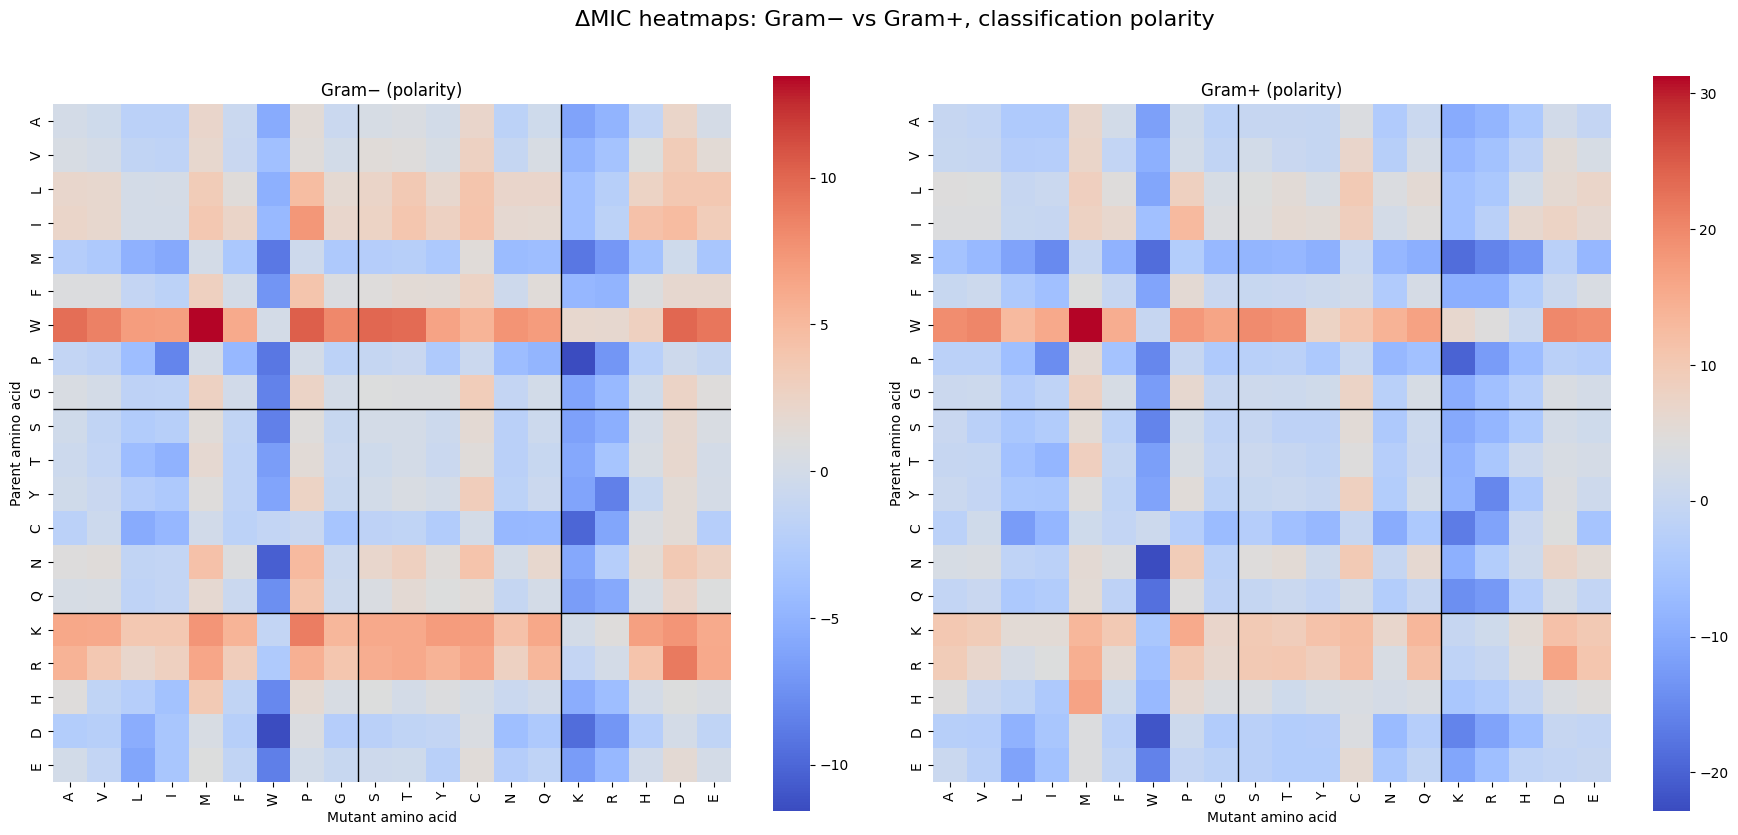

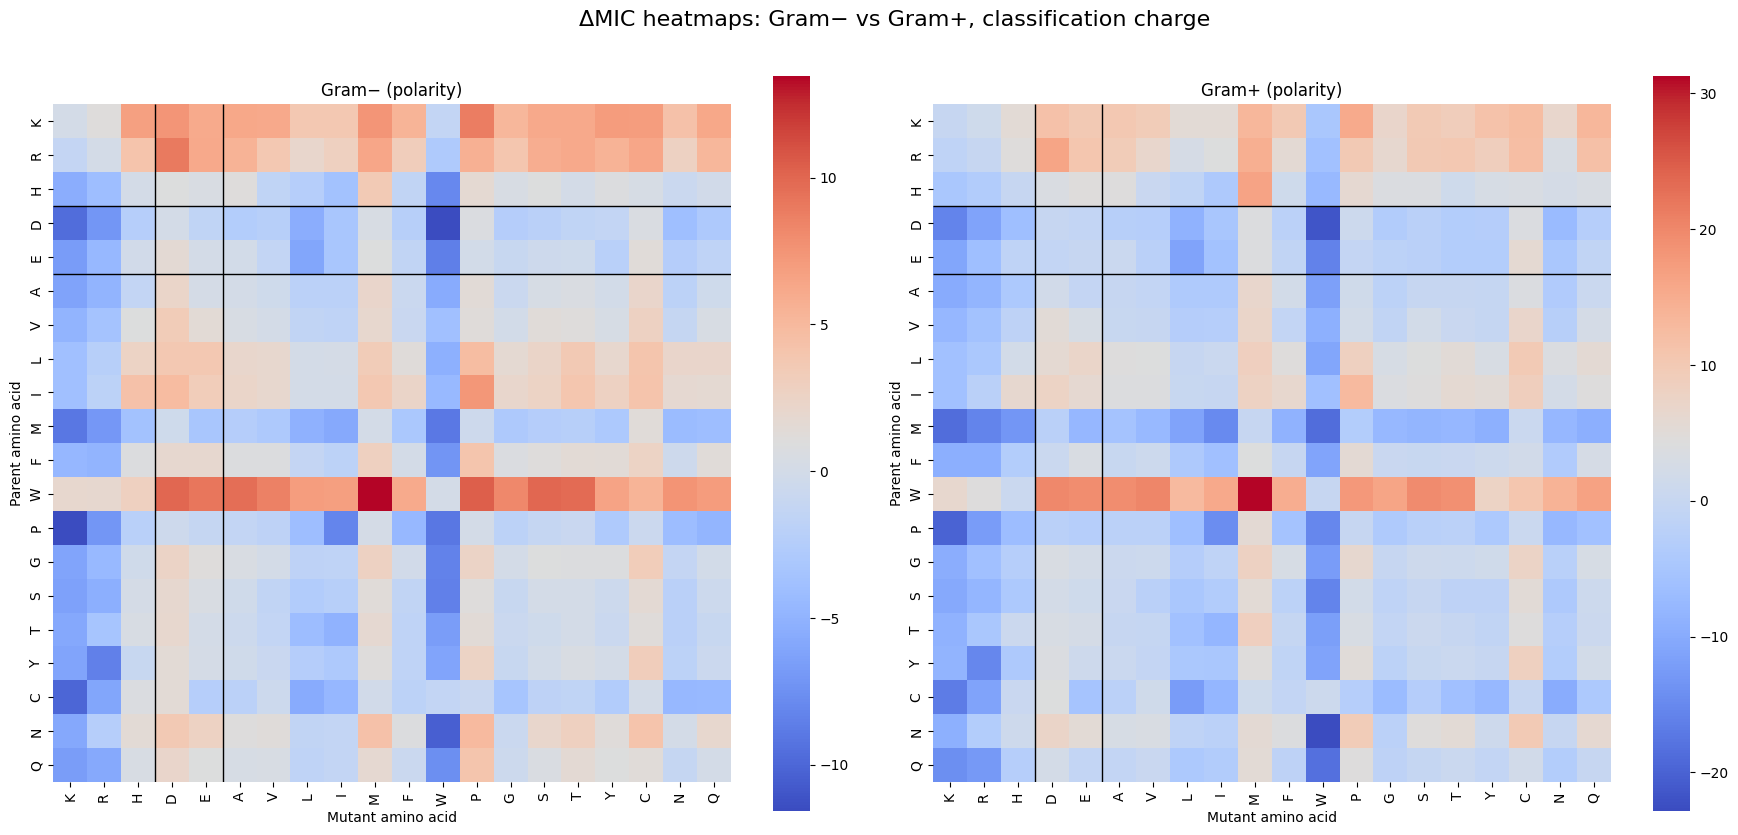

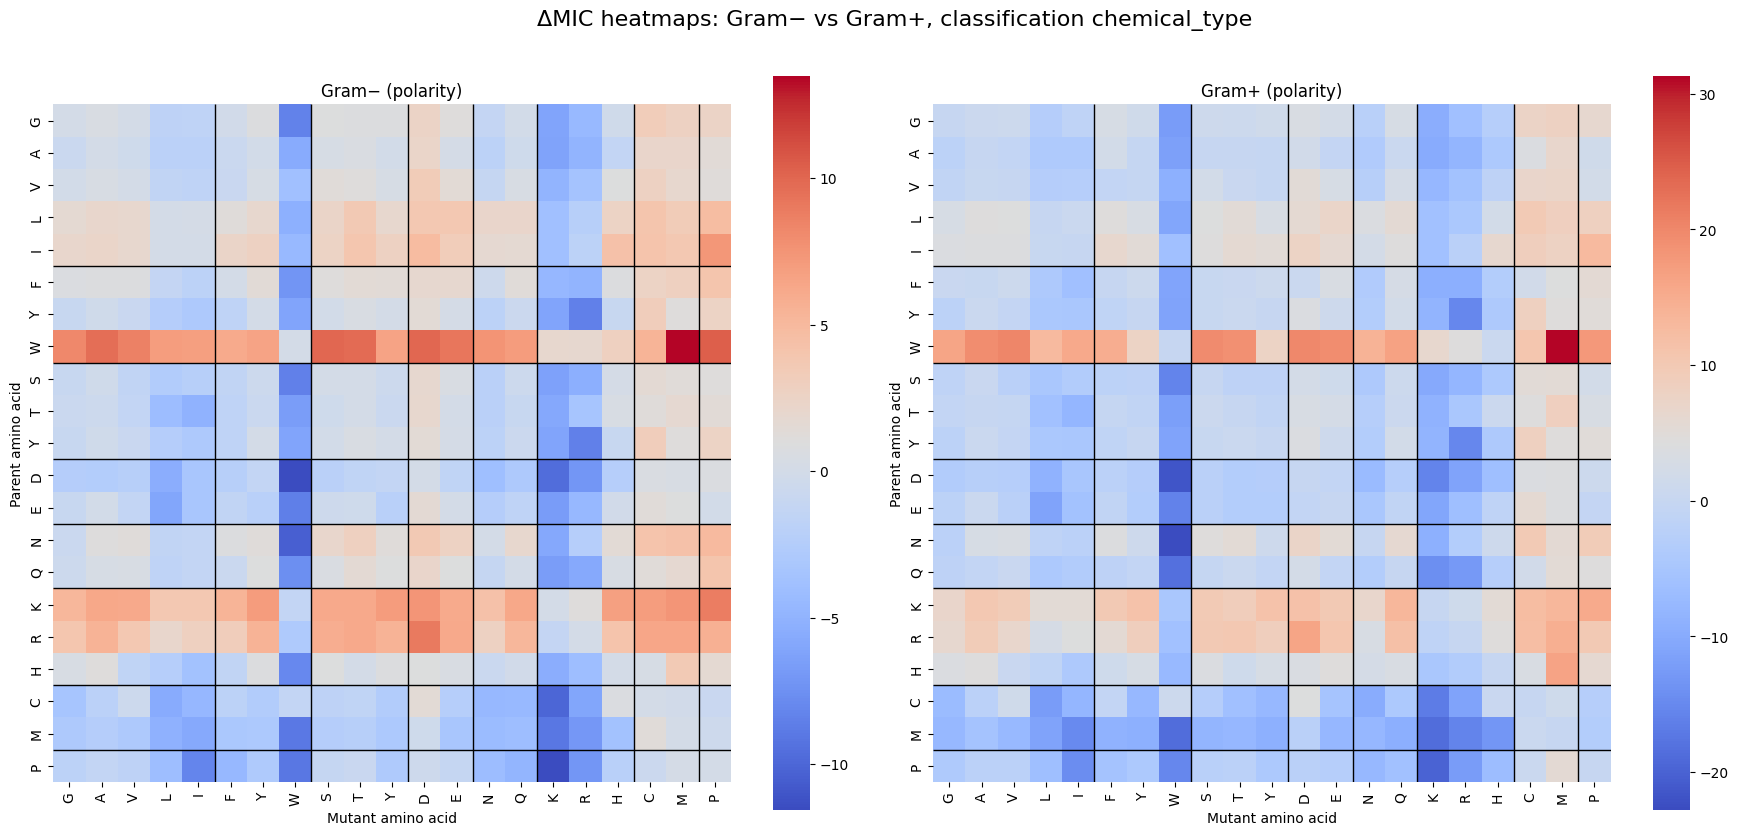

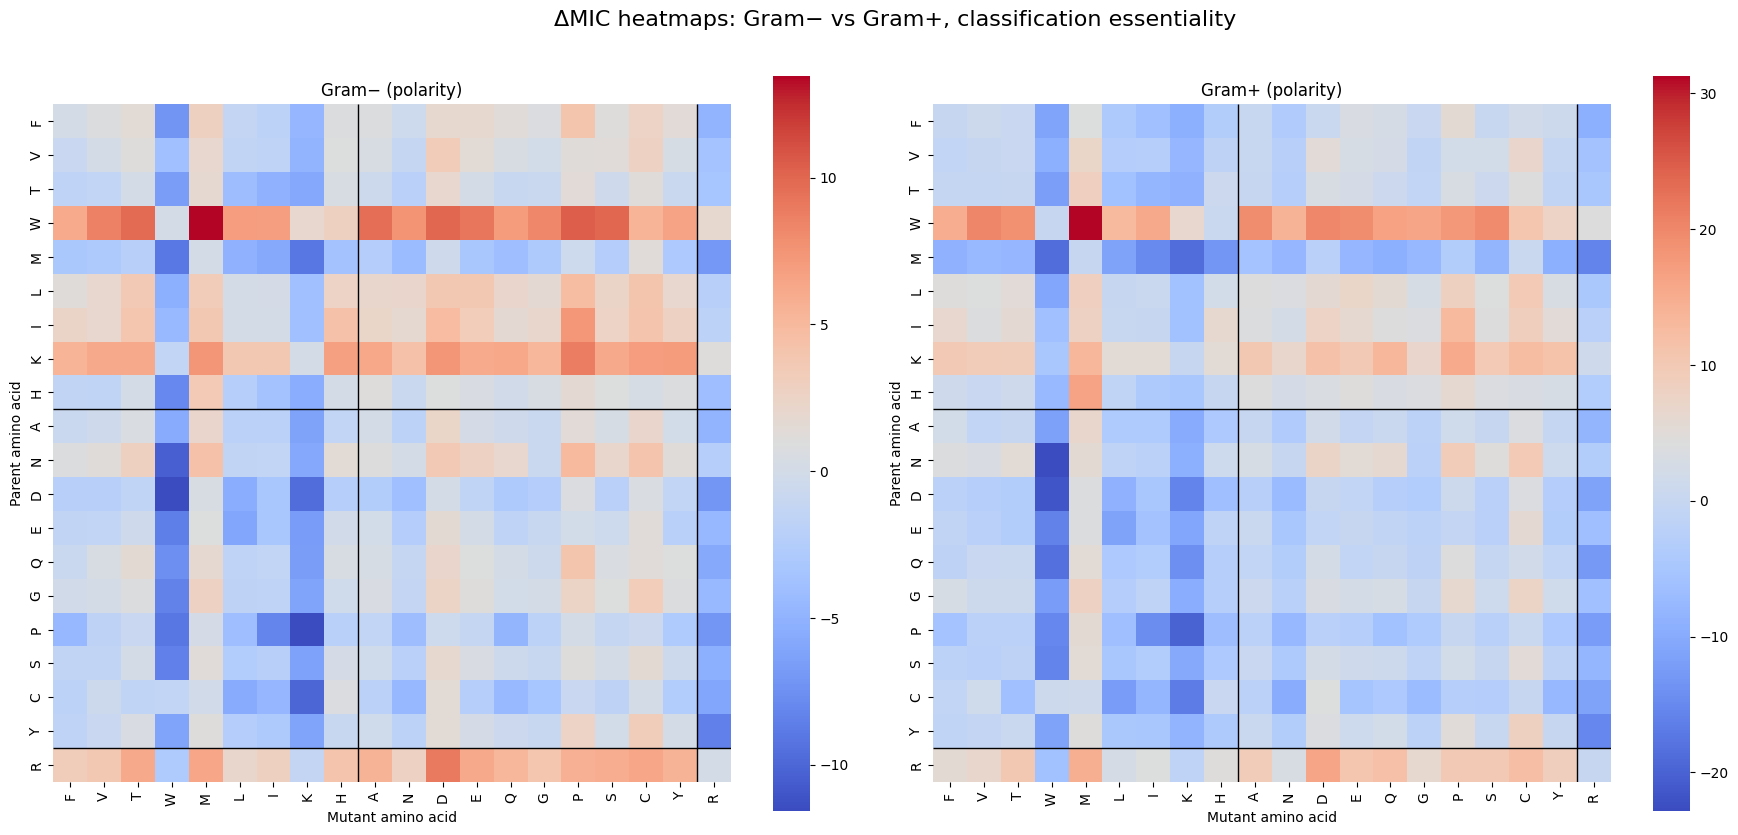

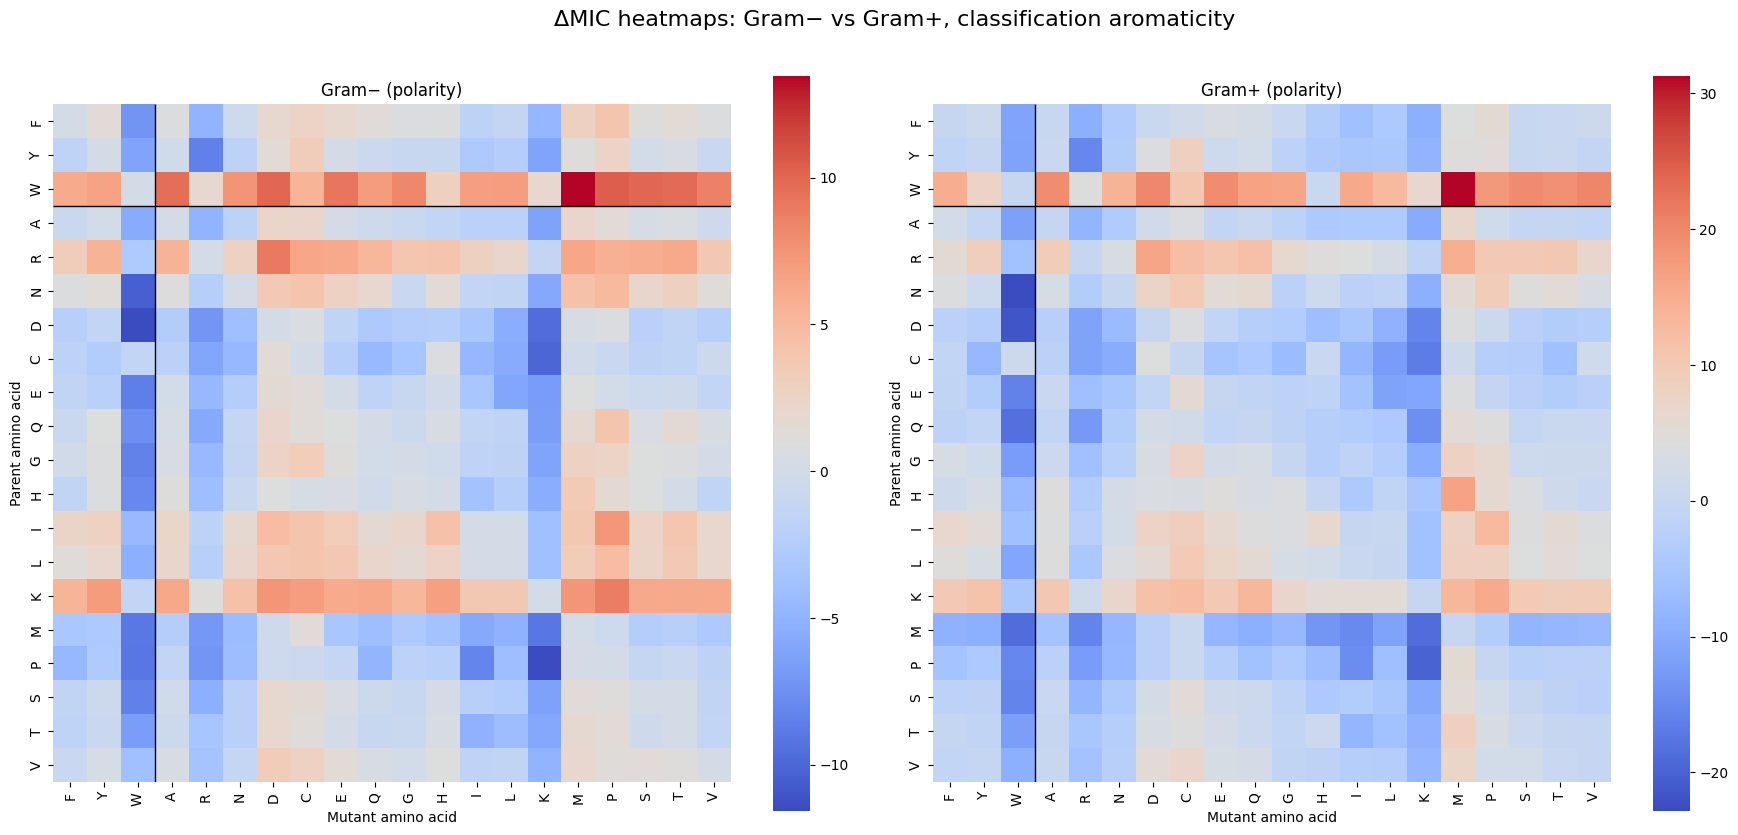

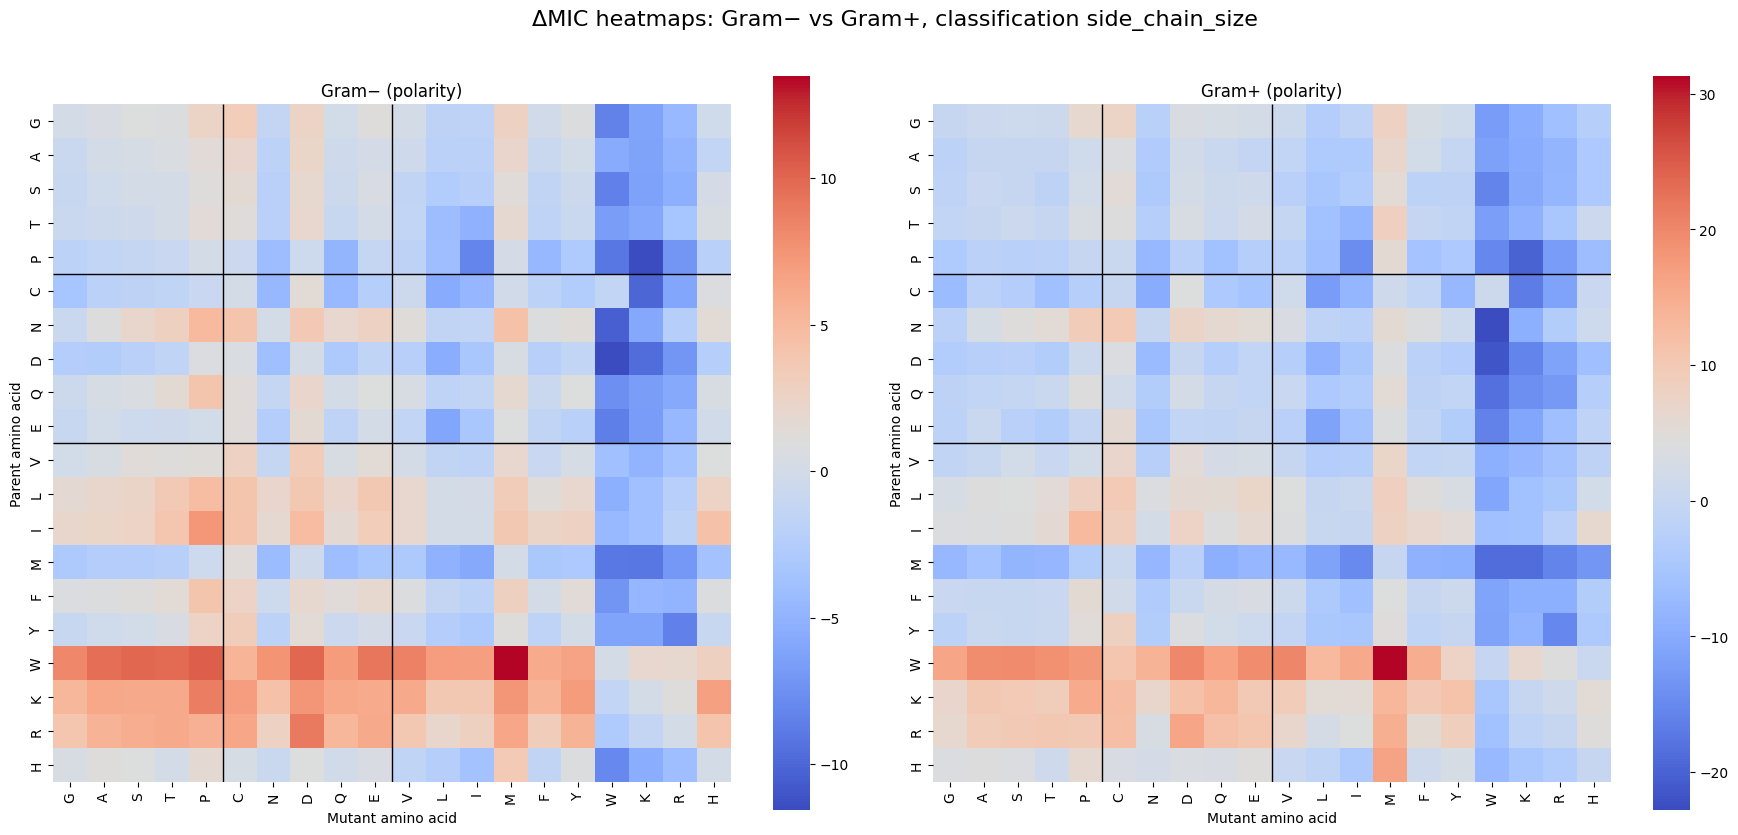

In [67]:
# Get figs + sorted dfs

for c in classes:
    fig_neg, ax_neg, df_neg_sorted, sorted_aas, boundaries_neg = create_square_plot(
        mean_gram_neg_matrix.astype(float).to_numpy(),
        classification=c,
        cmap="coolwarm",
        title="Gram-negative mean ΔMIC",
        return_fig=True,
        show_labels=True,
    )

    fig_pos, ax_pos, df_pos_sorted, _, boundaries_pos = create_square_plot(
        mean_gram_pos_matrix.astype(float).to_numpy(),
        classification=c,
        cmap="coolwarm",
        title="Gram-positive mean ΔMIC",
        return_fig=True,
        show_labels=True,
    )

    # Close the intermediate single figures (prevent double display)
    plt.close(fig_neg)
    plt.close(fig_pos)

    # Plot side-by-side using the sorted DataFrames directly
    fig_combined, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.heatmap(df_neg_sorted, cmap="coolwarm", square=True, ax=axes[0],
                xticklabels=sorted_aas, yticklabels=sorted_aas)
    sns.heatmap(df_pos_sorted, cmap="coolwarm", square=True, ax=axes[1],
                xticklabels=sorted_aas, yticklabels=sorted_aas)

    # re-draw boundaries for combined axes (use boundaries from create_square_plot)
    n = len(sorted_aas)
    for b in boundaries_neg[:-1]:
        axes[0].hlines(b, xmin=0, xmax=n, colors="black", linewidth=1)
        axes[0].vlines(b, ymin=0, ymax=n, colors="black", linewidth=1)
    for b in boundaries_pos[:-1]:
        axes[1].hlines(b, xmin=0, xmax=n, colors="black", linewidth=1)
        axes[1].vlines(b, ymin=0, ymax=n, colors="black", linewidth=1)

    axes[0].set_title("Gram− (polarity)")
    axes[1].set_title("Gram+ (polarity)")
    for ax in axes:
        ax.set_xlabel("Mutant amino acid")
        ax.set_ylabel("Parent amino acid")
        ax.set_xticklabels(sorted_aas, rotation=90)

    fig_combined.suptitle(f"ΔMIC heatmaps: Gram− vs Gram+, classification {c}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
